# Extension 5 — First-Delivery Birth Records: Adjusted Sector Comparison

**Research question.** Does the survey-weighted, covariate-standardized private–public Cesarean risk difference remain among births from a woman's first delivery, when a previous Cesarean is structurally impossible?

**Unit of analysis.** The parent analytic data contain birth records. This subgroup includes every birth record from a first delivery, including both children of a first twin delivery. A multiple delivery therefore can contribute more than one record, as in the parent analysis; this is a birth-record-weighted comparison, not a unique-delivery analysis. Respondent-grouped cross-fitting keeps a woman's records in one fold, and the existing PSU bootstrap resamples their cluster together. A unique-delivery sensitivity would answer a related, distinct question.

**Cohort rule.** The DHS birth-order calculation adjusts `birth_order` (`bord`) for multiple births using `twin_order` (`b0`): `delivery_order = birth_order - twin_order + 1` when `twin_order > 1`, and `birth_order` otherwise. Select `delivery_order == 1`. This includes 732 records that `birth_order == 1` omitted in the user's 27 September 2026 read-only check. It does not use `birth_index`.

**Interpretation.** The restriction removes prior-Cesarean history as a possible difference between sectors within this subgroup. Other clinical indications remain incompletely measured. The sector contrast remains associational; this notebook does not claim a causal effect of moving a woman between facilities.

**Run status.** The previous `birth_order == 1` version produced 82,426 birth records and a 28.9076 percentage-point adjusted gap. Those are historical results for a different cohort and must not be reported as this corrected first-delivery result. Rerun this version on the current processed data before interpreting any new numbers.


## 1. Imports, shared config/utils

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("../shared").resolve()))
import config
import utils

pd.set_option("display.max_columns", None)

OUTPUTS_DIR = config.EXT05_OUTPUTS_DIR
RANDOM_STATE = config.RANDOM_STATE
N_FOLDS = config.N_FOLDS
N_BOOTSTRAP = config.N_BOOTSTRAP

## 2. First-delivery birth-record cohort

Following the DHS multiple-birth adjustment, select `delivery_order == 1`, not `birth_order == 1` or `birth_index == 1`. The source remains a birth-record dataset; both records from a first twin delivery are included. Records missing `age_at_first_birth` are excluded from modeling and counted explicitly.


In [2]:
analytic, n_loaded, n_other = utils.load_public_private_analytic(
    config.V2_PROCESSED_DATA_PATH,
    expected_total_rows=config.EXPECTED_V2_ROW_COUNT,
    expected_analytic_rows=config.EXPECTED_ANALYTIC_ROW_COUNT,
)
print(f"Full analytic cohort (public + private): {len(analytic)}")

for col in ["birth_order", "twin_order"]:
    assert analytic[col].notna().all(), f"Missing {col}: check source before defining first deliveries."

# DHS birth-order convention: adjust the later child in a multiple birth.
analytic["delivery_order"] = analytic["birth_order"].where(
    analytic["twin_order"] <= 1,
    analytic["birth_order"] - analytic["twin_order"] + 1,
)
first_birth = analytic.loc[analytic["delivery_order"] == 1].copy()
raw_first_child = analytic["birth_order"] == 1
omitted_by_old_rule = int(((analytic["delivery_order"] == 1) & ~raw_first_child).sum())
print(f"First-delivery birth records: {len(first_birth)} "
      f"({len(first_birth) / len(analytic) * 100:.2f}% of analytic birth records)")
print(f"Additional birth records versus old birth_order == 1 rule: {omitted_by_old_rule}")
assert int(raw_first_child.sum()) == 82426, "Old cohort count changed; inspect input version."
assert len(first_birth) == 83158 and omitted_by_old_rule == 732, \
    "First-delivery count differs from the independent audit; inspect input and coding."

n_missing_age = int(first_birth["age_at_first_birth"].isna().sum())
first_birth_modeling = first_birth.loc[first_birth["age_at_first_birth"].notna()].copy()
print(f"Excluded for missing age_at_first_birth: {n_missing_age}")
print(f"First-delivery modeling birth records: {len(first_birth_modeling)}")


Full analytic cohort (public + private): 200794
First-delivery birth records: 83158 (41.41% of analytic birth records)
Additional birth records versus old birth_order == 1 rule: 732
Excluded for missing age_at_first_birth: 0
First-delivery modeling birth records: 83158


In [3]:
def sector_prevalence_table(df):
    rows = []
    for facility in ["public", "private"]:
        sub = df[df["facility_type"] == facility]
        rows.append({
            "facility_type": facility, "n": len(sub),
            "raw_csection_prevalence_pct": sub["csection"].mean() * 100 if len(sub) else np.nan,
            "weighted_csection_prevalence_pct": (
                np.average(sub["csection"], weights=sub["sample_weight_normalized"]) * 100 if len(sub) else np.nan
            ),
        })
    return pd.DataFrame(rows)


cohort_summary = sector_prevalence_table(first_birth_modeling)
cohort_summary.insert(0, "cohort", "first_delivery_birth_records_modeling")
cohort_summary.insert(1, "n_total", len(first_birth_modeling))
cohort_summary.insert(2, "n_excluded_missing_age_at_first_birth", n_missing_age)

cohort_summary.to_csv(OUTPUTS_DIR / "first_birth_cohort_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "first_birth_cohort_summary.csv")
cohort_summary

Saved: C:\Users\Tushna\IPD\extensions_work\05_first_birth\outputs\first_birth_cohort_summary.csv


,cohort,n_total,n_excluded_missing_age_at_first_birth,facility_type,n,raw_csection_prevalence_pct,weighted_csection_prevalence_pct
0,first_delivery_birth_records_modeling,83158,0,public,58797,17.403949,18.217931
1,first_delivery_birth_records_modeling,83158,0,private,24361,50.909240,51.625799


## 3. Confounder set in the first-delivery subgroup

`delivery_order` is constant at 1. Raw `birth_order` can differ between twins in the same first delivery, so its value here reflects child position rather than prior delivery history. It is excluded. `age_at_first_birth` (`v212`) is used as age at the analyzed first delivery; multiple-birth children share that age. `twin_order` remains in the categorical set, as in the teammate's original model. The outcome and population remain birth-record based.


In [4]:
FIRST_BIRTH_NUMERIC = ["age_at_first_birth", "wealth_index", "education_years"]
FIRST_BIRTH_CATEGORICAL = ["residence", "religion", "social_group", "twin_order", "state"]
FIRST_BIRTH_CONFOUNDERS = FIRST_BIRTH_NUMERIC + FIRST_BIRTH_CATEGORICAL

assert first_birth_modeling["delivery_order"].eq(1).all()
assert "birth_order" not in FIRST_BIRTH_CONFOUNDERS
assert "delivery_order" not in FIRST_BIRTH_CONFOUNDERS
print(f"First-delivery confounder set ({len(FIRST_BIRTH_CONFOUNDERS)}): {FIRST_BIRTH_CONFOUNDERS}")
print("Confirmed: delivery_order == 1 throughout; raw birth_order is excluded.")


First-delivery confounder set (8): ['age_at_first_birth', 'wealth_index', 'education_years', 'residence', 'religion', 'social_group', 'twin_order', 'state']
Confirmed: delivery_order == 1 throughout; raw birth_order is excluded.


## 4. Overlap and covariate-balance diagnostics within first-delivery birth records


In [5]:
W_diag = first_birth_modeling[FIRST_BIRTH_CONFOUNDERS].copy()
for col in FIRST_BIRTH_CATEGORICAL:
    W_diag[col] = W_diag[col].astype("string").fillna("Missing").astype(str)
for col in FIRST_BIRTH_NUMERIC:
    W_diag[col] = W_diag[col].fillna(W_diag[col].median())

exposure_fb = first_birth_modeling["exposure"].to_numpy()
weight_fb = first_birth_modeling["sample_weight_normalized"].to_numpy()

prop_pipeline = utils.make_propensity_pipeline(FIRST_BIRTH_NUMERIC, FIRST_BIRTH_CATEGORICAL, RANDOM_STATE)
prop_pipeline.fit(W_diag, exposure_fb, clf__sample_weight=weight_fb)
e_hat_diag = np.clip(prop_pipeline.predict_proba(W_diag)[:, 1], config.CLIP_EPS, 1 - config.CLIP_EPS)

marginal_private_fb = np.average(exposure_fb, weights=weight_fb)
stabilized_ipw_fb = np.where(
    exposure_fb == 1, marginal_private_fb / e_hat_diag, (1 - marginal_private_fb) / (1 - e_hat_diag)
)
combined_weight_fb = weight_fb * stabilized_ipw_fb

balance_dummies = pd.concat([
    W_diag[FIRST_BIRTH_NUMERIC],
    pd.get_dummies(W_diag[FIRST_BIRTH_CATEGORICAL], columns=FIRST_BIRTH_CATEGORICAL, prefix=FIRST_BIRTH_CATEGORICAL),
], axis=1)

exposure_mask_fb = exposure_fb == 1
unweighted_ones_fb = np.ones(len(first_birth_modeling))

balance_rows = []
for col in balance_dummies.columns:
    values = balance_dummies[col].to_numpy(dtype=float)
    smd_before = utils.smd(values[exposure_mask_fb], unweighted_ones_fb[exposure_mask_fb],
                            values[~exposure_mask_fb], unweighted_ones_fb[~exposure_mask_fb])
    smd_after = utils.smd(values[exposure_mask_fb], combined_weight_fb[exposure_mask_fb],
                           values[~exposure_mask_fb], combined_weight_fb[~exposure_mask_fb])
    balance_rows.append({"covariate": col, "smd_before": smd_before, "smd_after": smd_after})

first_birth_overlap_balance = pd.DataFrame(balance_rows).sort_values("smd_before", key=np.abs, ascending=False)
first_birth_overlap_balance["flag_after_weighting"] = first_birth_overlap_balance["smd_after"].abs() > 0.1
first_birth_overlap_balance.to_csv(OUTPUTS_DIR / "first_birth_overlap_balance.csv", index=False)

n_flagged = int(first_birth_overlap_balance["flag_after_weighting"].sum())
ess_private = utils.effective_sample_size(combined_weight_fb[exposure_mask_fb])
ess_public = utils.effective_sample_size(combined_weight_fb[~exposure_mask_fb])
print(f"Saved: {OUTPUTS_DIR / 'first_birth_overlap_balance.csv'}")
print(f"Covariates with |SMD| > 0.1 after weighting: {n_flagged} of {len(first_birth_overlap_balance)}")
print(f"Effective sample size after weighting -- private: {ess_private:.0f}, public: {ess_public:.0f}")
print(f"Common support (propensity) range: [{e_hat_diag.min():.4f}, {e_hat_diag.max():.4f}]")

Saved: C:\Users\Tushna\IPD\extensions_work\05_first_birth\outputs\first_birth_overlap_balance.csv
Covariates with |SMD| > 0.1 after weighting: 0 of 60
Effective sample size after weighting -- private: 10125, public: 22136
Common support (propensity) range: [0.0049, 0.9740]


## 5. Respondent-grouped cross-fitted AIPW (handoff step 41)

Same architecture as `notebooks/v2/07_aipw_primary_analysis.ipynb`, applied to the first-delivery birth-record cohort with its subgroup confounder set, via `shared/utils.run_cross_fitted_aipw`.

**Bootstrap scope, disclosed explicitly (external-review repair).** `run_cross_fitted_aipw`'s PSU-cluster bootstrap treats the already-fitted propensity/outcome nuisance predictions as fixed for every replicate -- it does not refit propensity or outcome models inside the bootstrap loop. This matches Notebook 07's own documented convention (see its metadata's `bootstrap.caveat`), so it is not a new limitation introduced here, but it means the reported CI is conditional on this one nuisance fit, not a full end-to-end refit-every-replicate uncertainty.

In [6]:
first_birth_result = utils.run_cross_fitted_aipw(
    first_birth_modeling, FIRST_BIRTH_CONFOUNDERS, FIRST_BIRTH_NUMERIC, FIRST_BIRTH_CATEGORICAL,
    n_folds=N_FOLDS, random_state=RANDOM_STATE, n_bootstrap=N_BOOTSTRAP, bootstrap_seed=config.BOOTSTRAP_SEED,
)

print(f"First-delivery birth-record adjusted private risk: {first_birth_result['r1'] * 100:.2f}%")
print(f"First-delivery birth-record adjusted public risk: {first_birth_result['r0'] * 100:.2f}%")
print(f"First-delivery birth-record adjusted RD: {first_birth_result['risk_difference'] * 100:.2f} pp "
      f"[{first_birth_result['rd_ci'][0] * 100:.2f}, {first_birth_result['rd_ci'][1] * 100:.2f}]")
print(f"First-delivery birth-record adjusted RR: {first_birth_result['risk_ratio']:.3f} "
      f"[{first_birth_result['rr_ci'][0]:.3f}, {first_birth_result['rr_ci'][1]:.3f}]")

First-delivery birth-record adjusted private risk: 49.72%
First-delivery birth-record adjusted public risk: 20.76%
First-delivery birth-record adjusted RD: 28.96 pp [27.90, 30.03]
First-delivery birth-record adjusted RR: 2.395 [2.318, 2.476]


## 6. Save AIPW summary and bootstrap results (handoff step 42)

In [7]:
first_birth_aipw_summary = pd.DataFrame([{
    "r1_hat_private_risk_pct": first_birth_result["r1"] * 100,
    "r0_hat_public_risk_pct": first_birth_result["r0"] * 100,
    "risk_difference_pct": first_birth_result["risk_difference"] * 100,
    "risk_difference_ci_low_pct": first_birth_result["rd_ci"][0] * 100,
    "risk_difference_ci_high_pct": first_birth_result["rd_ci"][1] * 100,
    "risk_ratio": first_birth_result["risk_ratio"],
    "risk_ratio_ci_low": first_birth_result["rr_ci"][0],
    "risk_ratio_ci_high": first_birth_result["rr_ci"][1],
    "n_analytic": first_birth_result["n"],
    "n_private": int((first_birth_modeling['exposure'] == 1).sum()),
    "n_public": int((first_birth_modeling['exposure'] == 0).sum()),
}])
first_birth_aipw_summary.to_csv(OUTPUTS_DIR / "first_birth_aipw_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "first_birth_aipw_summary.csv")

first_birth_bootstrap_summary = pd.DataFrame({
    "replicate": np.arange(N_BOOTSTRAP),
    "risk_difference_pct": first_birth_result["rd_reps"] * 100,
    "risk_ratio": first_birth_result["rr_reps"],
})
first_birth_bootstrap_summary.to_csv(OUTPUTS_DIR / "first_birth_bootstrap_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "first_birth_bootstrap_summary.csv")
first_birth_aipw_summary

Saved: C:\Users\Tushna\IPD\extensions_work\05_first_birth\outputs\first_birth_aipw_summary.csv
Saved: C:\Users\Tushna\IPD\extensions_work\05_first_birth\outputs\first_birth_bootstrap_summary.csv


,r1_hat_private_risk_pct,r0_hat_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,n_analytic,n_private,n_public
0,49.720163,20.756362,28.963801,27.902901,30.032284,2.395418,2.317963,2.475595,83158,24361,58797


## 7. Comparison with the full-cohort primary estimate (handoff step 43)

**Why this is a side-by-side comparison, not a formal joint confidence interval for the difference.**
First-delivery birth records are a *subset* of the full analytic cohort, not an independent sample (unlike Extension 3's
NFHS-4-vs-NFHS-5 comparison, where the two samples genuinely don't overlap). Pairing this notebook's bootstrap
replicates index-by-index against the frozen primary model's replicates (`outputs/tables/b4_aipw_bootstrap_results.csv`)
the way Extension 3 does for NFHS-4/NFHS-5 would silently assume independence that does not hold here, understating
the true correlation between the two estimates and producing an invalid interval. A statistically valid joint CI
would require re-resampling the *same* PSU draws for both models inside one bootstrap loop using saved row-level
nuisance predictions from both fits -- which needs the full-cohort's row-level nuisance file (not guaranteed to
exist locally) and roughly doubles the computational cost. That is flagged here as a possible future enhancement,
not implemented by default, rather than shipping a comparison that looks rigorous but isn't.

In [8]:
frozen_primary_path = config.V2_FINAL_TABLES_DIR / "final_aipw_overall_table.csv"
frozen_primary = pd.read_csv(frozen_primary_path).iloc[0]

comparison = pd.DataFrame([
    {"cohort": "full_cohort_primary (Notebook 07)", "n": int(frozen_primary["n_analytic"]),
     "risk_difference_pct": frozen_primary["risk_difference_pct"],
     "ci_low_pct": frozen_primary["risk_difference_ci_low_pct"], "ci_high_pct": frozen_primary["risk_difference_ci_high_pct"],
     "risk_ratio": frozen_primary["risk_ratio"],
     "rr_ci_low": frozen_primary["risk_ratio_ci_low"], "rr_ci_high": frozen_primary["risk_ratio_ci_high"]},
    {"cohort": "first_delivery_birth_records (this notebook)", "n": first_birth_result["n"],
     "risk_difference_pct": first_birth_result["risk_difference"] * 100,
     "ci_low_pct": first_birth_result["rd_ci"][0] * 100, "ci_high_pct": first_birth_result["rd_ci"][1] * 100,
     "risk_ratio": first_birth_result["risk_ratio"],
     "rr_ci_low": first_birth_result["rr_ci"][0], "rr_ci_high": first_birth_result["rr_ci"][1]},
])

print(comparison)
print("\nBoth estimates and their independently-computed CIs are shown side by side. No formal statistical "
      "test is applied to their difference here: first-delivery births are a SUBSET of, not independent from, the full "
      "cohort, so whether their marginal CIs happen to overlap is not a valid test of whether the two "
      "estimates differ (repair per external review -- see Section 7 markdown above and the notebook's "
      "final documentation section for why a valid joint test needs a paired/joint resampling design instead).")

                                         cohort       n  risk_difference_pct  \
0             full_cohort_primary (Notebook 07)  200794            28.469798   
1  first_delivery_birth_records (this notebook)   83158            28.963801   

   ci_low_pct  ci_high_pct  risk_ratio  rr_ci_low  rr_ci_high  
0   27.671957    29.244259    2.726007   2.656604    2.803453  
1   27.902901    30.032284    2.395418   2.317963    2.475595  

Both estimates and their independently-computed CIs are shown side by side. No formal statistical test is applied to their difference here: first-delivery births are a SUBSET of, not independent from, the full cohort, so whether their marginal CIs happen to overlap is not a valid test of whether the two estimates differ (repair per external review -- see Section 7 markdown above and the notebook's final documentation section for why a valid joint test needs a paired/joint resampling design instead).


## 8. Figure -- comparison forest plot

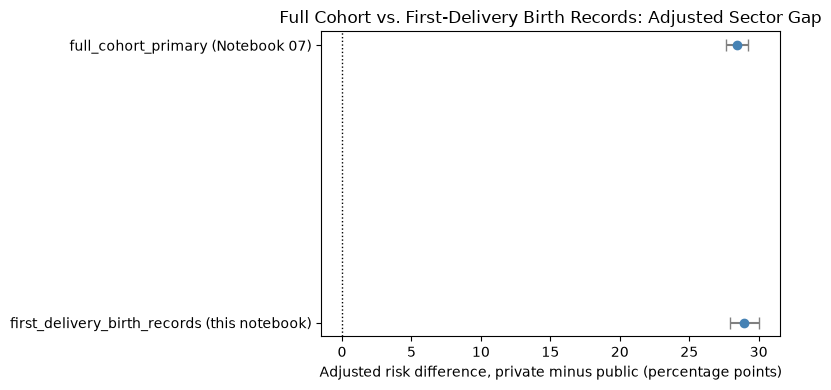

Saved: C:\Users\Tushna\IPD\extensions_work\05_first_birth\outputs\first_birth_comparison_plot.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = [0, 1]
ax.errorbar(
    comparison["risk_difference_pct"], y_pos,
    xerr=[comparison["risk_difference_pct"] - comparison["ci_low_pct"], comparison["ci_high_pct"] - comparison["risk_difference_pct"]],
    fmt="o", color="steelblue", ecolor="gray", capsize=4,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(comparison["cohort"])
ax.invert_yaxis()
ax.axvline(0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Adjusted risk difference, private minus public (percentage points)")
ax.set_title("Full Cohort vs. First-Delivery Birth Records: Adjusted Sector Gap")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "first_birth_comparison_plot.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "first_birth_comparison_plot.png")

## 9. QA / interpretation checks (explicit)

In [10]:
print("First-delivery cohort verified: delivery_order == 1 with the DHS multiple-birth adjustment.")
print(f"Birth records added versus birth_order == 1: {omitted_by_old_rule}")
print(f"Records excluded for missing age_at_first_birth: {n_missing_age}")
print("The analysis unit remains a birth record; first twin deliveries can contribute two records.")
print("Raw birth_order and constant delivery_order are excluded from predictors.")
print("Prior Cesarean history is impossible at a first delivery. Other unmeasured clinical indications")
print("may remain; this is an associational sector comparison, not a causal facility effect.")


First-delivery cohort verified: delivery_order == 1 with the DHS multiple-birth adjustment.
Birth records added versus birth_order == 1: 732
Records excluded for missing age_at_first_birth: 0
The analysis unit remains a birth record; first twin deliveries can contribute two records.
Raw birth_order and constant delivery_order are excluded from predictors.
Prior Cesarean history is impossible at a first delivery. Other unmeasured clinical indications
may remain; this is an associational sector comparison, not a causal facility effect.


## 10. Save metadata

In [11]:
metadata = {
    "random_state": RANDOM_STATE,
    "cohort": {
        "definition": "birth records from delivery_order == 1; multiple-birth adjustment uses twin_order",
        "unit": "birth record, not unique delivery",
        "n_first_delivery_birth_records": int(len(first_birth)),
        "n_added_vs_birth_order_eq_1": omitted_by_old_rule,
        "n_excluded_missing_age_at_first_birth": n_missing_age,
        "n_modeling_birth_records": int(len(first_birth_modeling)),
    },
    "confounder_set": FIRST_BIRTH_CONFOUNDERS,
    "birth_order_excluded_reason": "Raw child order is not prior-delivery order among twins at first delivery.",
    "delivery_order_excluded_reason": "Constant at 1 in this cohort.",
    "age_at_first_birth_included_reason": "Age at the analyzed first delivery, including multiple-birth records.",
    "nuisance_models": "same architecture as Notebook 07, refit on the first-delivery subgroup",
    "bootstrap_scope": "PSU resampling with fitted nuisance predictions held fixed; no refit per replicate",
    "comparison_to_primary": {
        "method": "side-by-side estimates and CIs; no formal joint difference CI",
        "reason": "First-delivery birth records are a subset of the full cohort, so the estimates are correlated.",
        "full_cohort_rd_pct": float(frozen_primary["risk_difference_pct"]),
        "first_delivery_birth_records_rd_pct": float(first_birth_result["risk_difference"] * 100),
    },
    "limitations": [
        "Birth-record unit gives multiple deliveries multiple rows; unique-delivery results could differ.",
        "Prior Cesarean history is excluded by first-delivery restriction, but other indications remain incompletely measured.",
        "Sector contrast is associational, not a causal facility-choice effect.",
    ],
}
with open(OUTPUTS_DIR / "first_birth_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved:", OUTPUTS_DIR / "first_birth_metadata.json")


Saved: C:\Users\Tushna\IPD\extensions_work\05_first_birth\outputs\first_birth_metadata.json


## 11. Documentation and limitations

The first-delivery definition adjusts child birth order for multiple births. This includes both records from a first twin delivery and preserves the parent analysis's birth-record unit. Consequently, a multiple delivery can receive more total birth-record weight than a singleton delivery; this analysis should not be labeled a unique-delivery analysis. Respondent-grouped folds and PSU resampling preserve within-woman grouping in the existing utility, but they do not change the unit of the point estimate.

`age_at_first_birth` is relevant to this subgroup, whereas raw `birth_order` is a child-position artifact among first-delivery twins and `delivery_order` is constant. The nuisance models are fitted on this subgroup rather than reused from the full cohort.

The full-cohort and subgroup estimates overlap in observations. Their marginal confidence intervals are displayed descriptively; overlap or non-overlap is not a test of their difference. The existing bootstrap holds fitted nuisance predictions fixed, so its intervals do not include model-refitting variability. Publication uncertainty remains subject to the project's statistical review.

The restriction removes one specific concern—previous Cesarean history—within the first-delivery subgroup. It does not remove other unmeasured clinical indications or turn the sector contrast into a causal effect.
